# QuickDraw Model

## Import relevant Libraries

In [1]:
import os 
import numpy as np

## Load .npy Files

In [3]:
QD_DIR = r"../quickdraw_npy"  # change this

core_classes = ["face", "eye", "mouth", "nose", "finger", "foot"]

data = {}
for c in core_classes:
    path = os.path.join(QD_DIR, f"{c}.npy")
    arr = np.load(path)  # shape (N, 784)
    data[c] = arr
    print(c, arr.shape, arr.dtype)

face (161666, 784) uint8
eye (125888, 784) uint8
mouth (134135, 784) uint8
nose (197573, 784) uint8
finger (167957, 784) uint8
foot (203086, 784) uint8


In [4]:
SAMPLES_PER_CLASS = 20000 # baseline


## Building x, y from QuickDraw classes

In [5]:
X_list, y_list = [], []
label_map = {c:i for i,c in enumerate(core_classes)}

In [6]:
for c in core_classes:
    arr = data[c]
    idx = np.random.choice(len(arr), size=min(SAMPLES_PER_CLASS, len(arr)), replace=False)
    X_list.append(arr[idx])
    y_list.append(np.full(len(idx), label_map[c], dtype=np.int64))

In [7]:
X_qd = np.vstack(X_list)  # (num_samples, 784)
y_qd = np.concatenate(y_list)

Normalize to 0-1 and reshape to 28x28

In [8]:
X_qd = (X_qd / 255.0).reshape(-1, 28, 28, 1)

print("X_qd:", X_qd.shape, "y_qd:", y_qd.shape)

X_qd: (120000, 28, 28, 1) y_qd: (120000,)


## Adding Other Class

In [9]:
import cv2, random

In [10]:
DRAW_ROOT = r"../../dataset/Dataset/Images/Emotion/train"

all_imgs = []

for emotion in os.listdir(DRAW_ROOT):
    emotion_dir = os.path.join(DRAW_ROOT, emotion)
    if not os.path.isdir(emotion_dir):
        continue

    for f in os.listdir(emotion_dir):
        if f.lower().endswith((".png", ".jpg", ".jpeg")):
            all_imgs.append(os.path.join(emotion_dir, f))

print("Total images collected:", len(all_imgs))

Total images collected: 9228


In [11]:
def random_crop_28(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    h, w = img.shape
    if h < 40 or w < 40:
        return None
    # random crop larger then resize to 28
    ch, cw = random.randint(40, min(200,h)), random.randint(40, min(200,w))
    y0 = random.randint(0, h - ch)
    x0 = random.randint(0, w - cw)
    crop = img[y0:y0+ch, x0:x0+cw]
    crop = cv2.resize(crop, (28,28))
    # invert like quickdraw (white bg, dark strokes) -> quickdraw has white lines on black?
    # quickdraw bitmaps are black background with white strokes usually.
    # We'll standardize: strokes=white, background=black:
    crop = 255 - crop
    crop = (crop / 255.0).astype("float32")
    return crop.reshape(28,28,1)

In [12]:
N_OTHER = 20000
other_crops = []
while len(other_crops) < N_OTHER:
    p = random.choice(all_imgs)
    c = random_crop_28(p)
    if c is not None:
        other_crops.append(c)

In [13]:
X_other = np.stack(other_crops)
y_other = np.full(N_OTHER, len(core_classes), dtype=np.int64)

In [14]:
print("X_other:", X_other.shape)

X_other: (20000, 28, 28, 1)


In [15]:
print("X_qd:", X_qd.shape)
print("y_qd:", y_qd.shape)
print("Unique labels in y_qd:", sorted(set(y_qd.tolist()))[:10], "...")

X_qd: (120000, 28, 28, 1)
y_qd: (120000,)
Unique labels in y_qd: [0, 1, 2, 3, 4, 5] ...


## Combining QuickDraw + OTHER into a training set

In [16]:
# y_other should be the last class index
y_other = np.full(len(X_other), len(core_classes), dtype=np.int64)

X = np.concatenate([X_qd, X_other], axis=0)
y = np.concatenate([y_qd, y_other], axis=0)

class_names = core_classes + ["other"]

print("X:", X.shape, "y:", y.shape)
print("num_classes:", len(class_names), class_names)


X: (140000, 28, 28, 1) y: (140000,)
num_classes: 7 ['face', 'eye', 'mouth', 'nose', 'finger', 'foot', 'other']


## Split the Data

In [17]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Build the Model

In [19]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

In [20]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Train the Model

In [21]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=6,
    batch_size=256
)

Epoch 1/6
438/438 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.8536 - loss: 0.4552 - val_accuracy: 0.9095 - val_loss: 0.2738
Epoch 2/6
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9126 - loss: 0.2694 - val_accuracy: 0.9157 - val_loss: 0.2497
Epoch 3/6
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9247 - loss: 0.2317 - val_accuracy: 0.9321 - val_loss: 0.2054
Epoch 4/6
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9308 - loss: 0.2103 - val_accuracy: 0.9366 - val_loss: 0.1896
Epoch 5/6
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9365 - loss: 0.1910 - val_accuracy: 0.9390 - val_loss: 0.1815
Epoch 6/6
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9414 - loss: 0.1766 - val_accuracy: 0.9399 - val_loss: 0.1777


## Test the Model

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

In [24]:
y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
print(classification_report(y_val, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        face       0.96      0.93      0.94      4000
         eye       0.94      0.95      0.95      4000
       mouth       0.93      0.95      0.94      4000
        nose       0.91      0.91      0.91      4000
      finger       0.92      0.95      0.94      4000
        foot       0.93      0.89      0.91      4000
       other       1.00      0.99      1.00      4000

    accuracy                           0.94     28000
   macro avg       0.94      0.94      0.94     28000
weighted avg       0.94      0.94      0.94     28000



## Test on Real Drawings

### Propose Candidate Boxes

In [28]:
def get_component_boxes(img_path, min_area=250):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, []

    bin_img = cv2.adaptiveThreshold(
        img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 35, 7
    )
    bin_img = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, np.ones((3,3),np.uint8), 1)

    num, _, stats, _ = cv2.connectedComponentsWithStats(bin_img, connectivity=8)

    boxes = []
    for i in range(1, num):
        x,y,w,h,area = stats[i]
        if area >= min_area:
            boxes.append((x,y,w,h))
    return img, boxes


In [29]:
def classify_boxes(img_gray, boxes):
    preds = []
    for (x,y,w,h) in boxes:
        crop = img_gray[y:y+h, x:x+w]
        crop = cv2.resize(crop, (28,28))
        crop = 255 - crop  # match quickdraw stroke polarity
        crop = (crop/255.0).astype("float32").reshape(1,28,28,1)

        prob = model.predict(crop, verbose=0)[0]
        cls = int(np.argmax(prob))
        conf = float(np.max(prob))
        preds.append((x,y,w,h, cls, conf))
    return preds

Visualization on 10 images

In [30]:
import math

def box_center(b):
    x,y,w,h = b
    return (x + w/2.0, y + h/2.0)

def box_union(boxes):
    xs = [b[0] for b in boxes]
    ys = [b[1] for b in boxes]
    x2 = [b[0]+b[2] for b in boxes]
    y2 = [b[1]+b[3] for b in boxes]
    x1, y1, x3, y3 = min(xs), min(ys), max(x2), max(y2)
    return (int(x1), int(y1), int(x3-x1), int(y3-y1))

def build_person_boxes(preds, face_thr=0.80, part_thr=0.75, k=2.5):
    # preds: (x,y,w,h, cls, conf)
    name_of = lambda cls: class_names[cls]

    faces = [(x,y,w,h,conf) for x,y,w,h,cls,conf in preds
             if name_of(cls)=="face" and conf>=face_thr]

    parts = [(x,y,w,h,name_of(cls),conf) for x,y,w,h,cls,conf in preds
             if name_of(cls)!="other" and name_of(cls)!="face" and conf>=part_thr]

    persons = []
    for fx,fy,fw,fh,fconf in faces:
        fbox = (fx,fy,fw,fh)
        fc = box_center(fbox)
        face_scale = math.hypot(fw, fh)  # face size scale
        attach = [fbox]

        for px,py,pw,ph,pname,pconf in parts:
            pbox = (px,py,pw,ph)
            pc = box_center(pbox)
            d = math.hypot(pc[0]-fc[0], pc[1]-fc[1])
            if d <= k * face_scale:
                attach.append(pbox)

        persons.append({
            "person_box": box_union(attach),
            "face_box": fbox,
            "attached_parts": attach
        })

    return persons

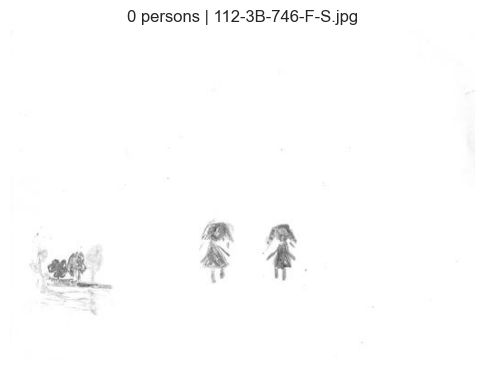

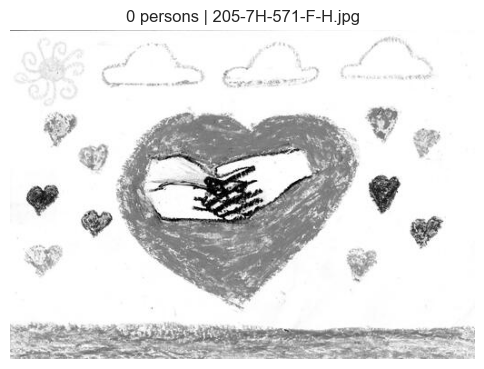

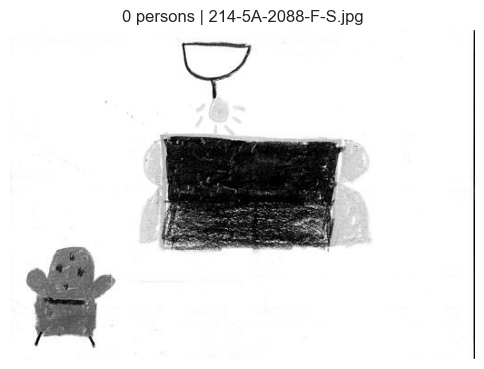

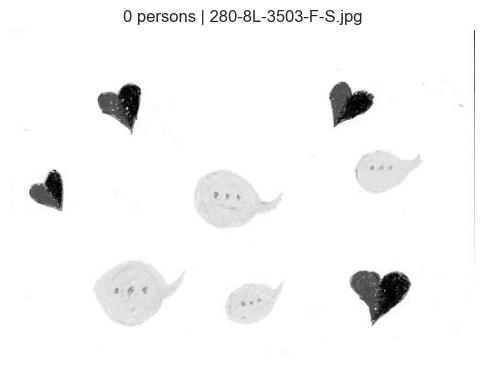

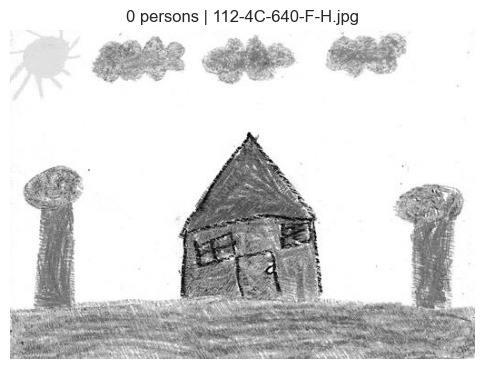

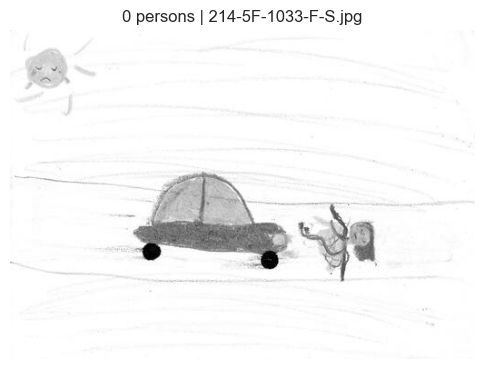

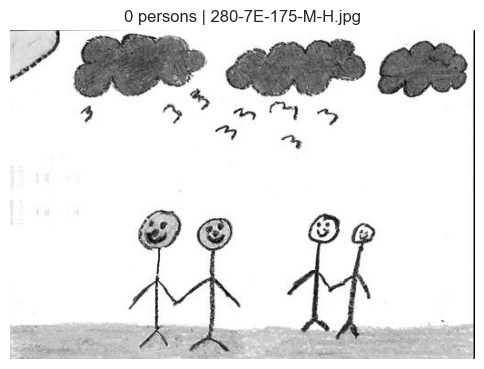

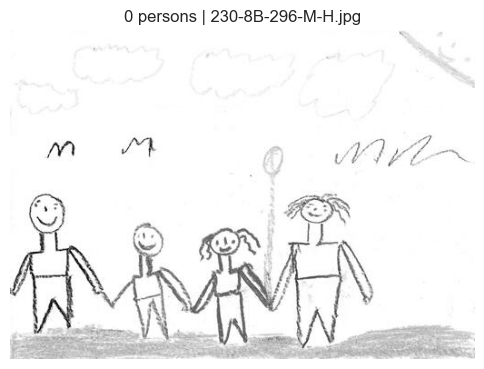

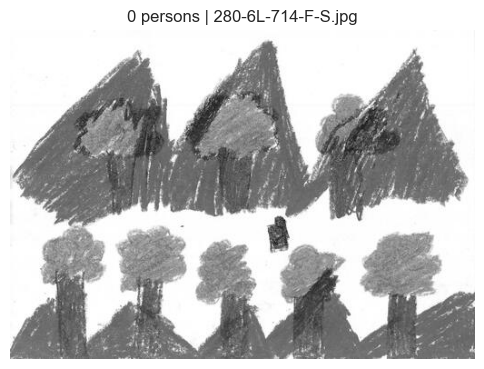

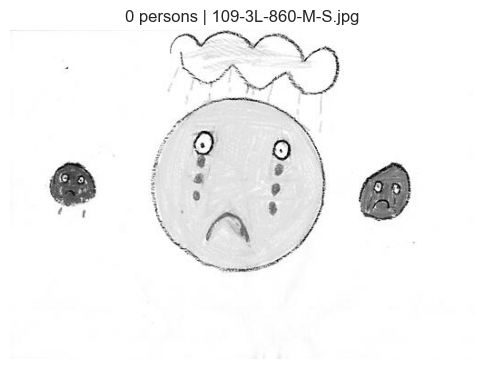

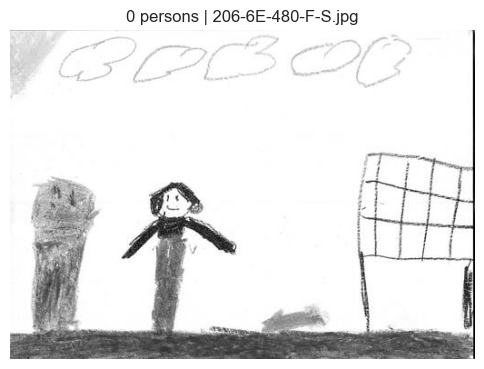

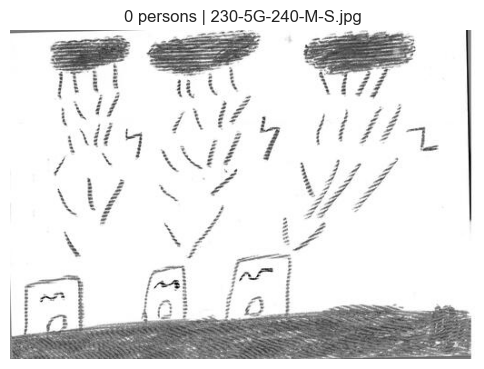

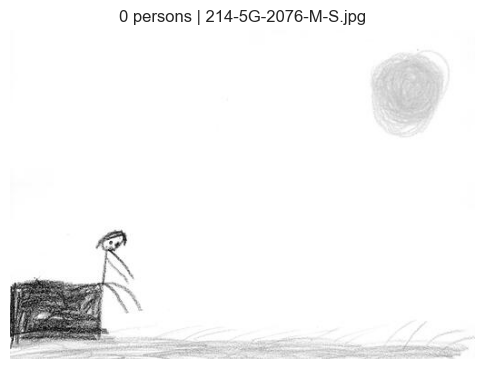

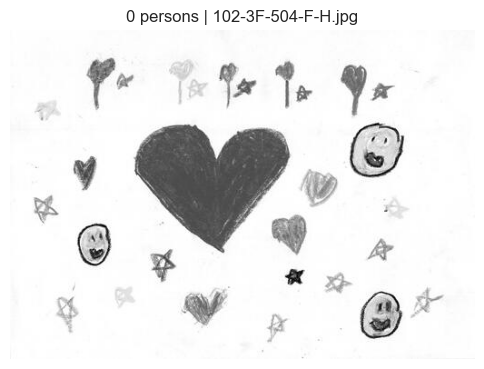

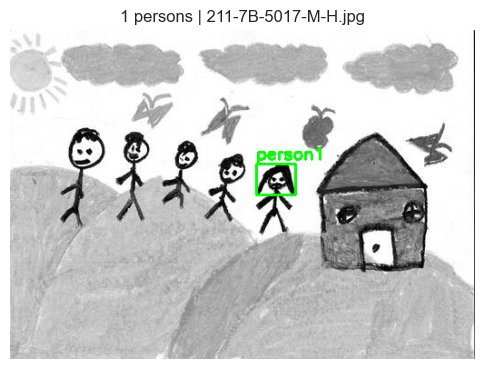

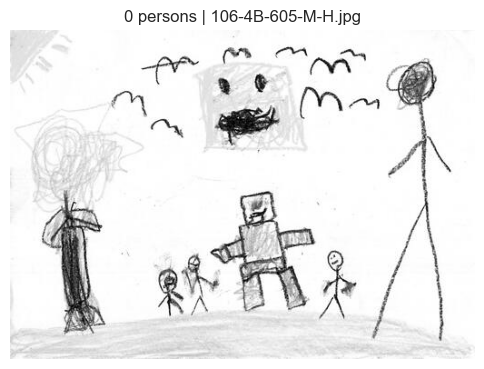

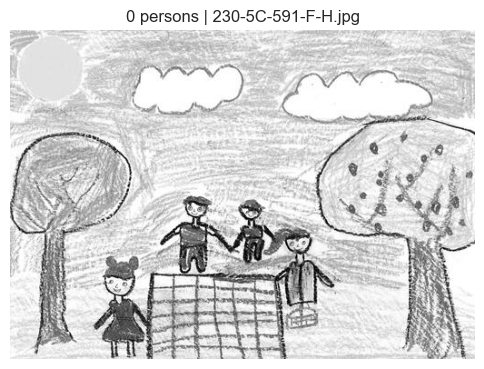

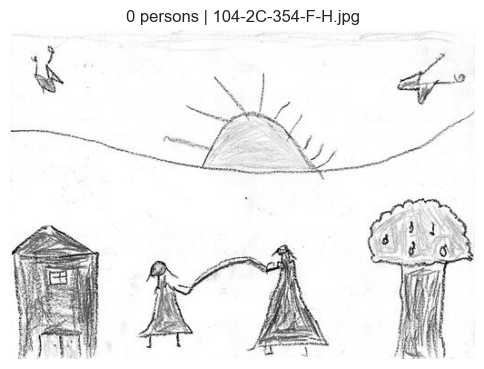

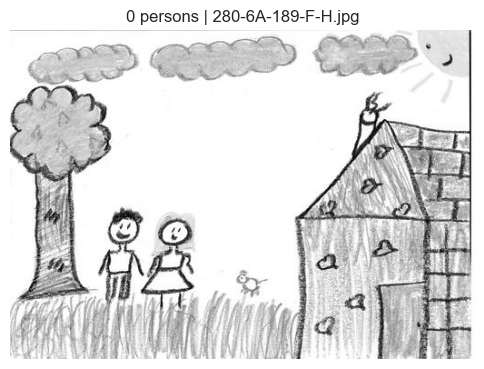

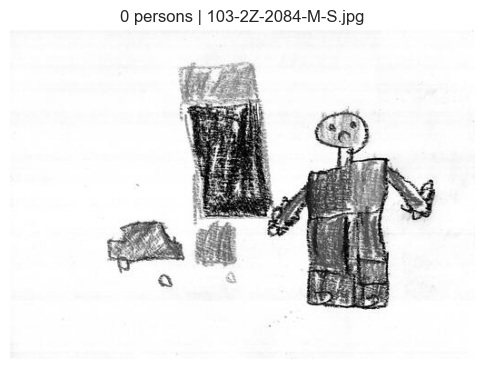

In [31]:
import random, matplotlib.pyplot as plt

def show_person_boxes(img_path):
    img_gray, boxes = get_component_boxes(img_path, min_area=250)
    if img_gray is None:
        return

    preds = classify_boxes(img_gray, boxes)
    persons = build_person_boxes(preds, face_thr=0.80, part_thr=0.75, k=2.5)

    vis = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)

    for i, p in enumerate(persons):
        x,y,w,h = p["person_box"]
        cv2.rectangle(vis, (x,y), (x+w,y+h), (0,255,0), 2)
        cv2.putText(vis, f"person{i+1}", (x, max(10,y-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"{len(persons)} persons | {img_path.split(os.sep)[-1]}")
    plt.show()

for p in random.sample(all_imgs, 20):
    show_person_boxes(p)

In [32]:
def relational_indicators(persons, img_shape):
    h, w = img_shape
    diag = math.hypot(w, h)

    boxes = [p["person_box"] for p in persons]
    centers = [box_center(b) for b in boxes]
    areas = [b[2]*b[3] for b in boxes]

    n = len(boxes)
    if n == 0:
        return {"num_people": 0}

    # pairwise distances
    dists = []
    nearest = []
    for i in range(n):
        di = []
        for j in range(n):
            if i == j: 
                continue
            d = math.hypot(centers[i][0]-centers[j][0], centers[i][1]-centers[j][1]) / diag
            di.append(d)
            dists.append(d)
        nearest.append(min(di) if di else None)

    grouping_score = float(np.mean(nearest)) if n > 1 else None
    isolation_score = float(max(nearest)) if n > 1 else None
    size_imbalance = float(max(areas) / (min(areas)+1e-9)) if n > 1 else None

    return {
        "num_people": n,
        "grouping_score": grouping_score,   # lower = more grouped
        "isolation_score": isolation_score, # higher = someone far away
        "size_imbalance": size_imbalance
    }